In [1]:
from pathlib import Path
import pandas as pd

from snowflakes import snowflake_connect

# Connect using SSO
conn = snowflake_connect()

# Read SQL file
sql = Path("space_opti_code.sql").read_text(encoding="utf-8")

# Execute
with conn.cursor() as cur:
    cur.execute(sql)
    df = cur.fetch_pandas_all()

# print(df.head())

# conn.close()

Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://bunnings.australia-east.privatelink.snowflakecomputing.com/console/login?login_name=267714&browser_mode_redirect_port=49682&proof_key=Ile%2F37BV90UVgfwzFc9ktFRn397BgE8fjKMKtCFn1L4%3D&authenticator=EXTERNALBROWSER to authenticate...
A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings.
Connection OK


In [4]:
df[df['FACINGS']==1]

,SALES_START_DATE,SALES_END_DATE,FIRST_SALES_DATE,EARLIEST_INVENTORY_STOCK_MOVEMENT_DATE,CURRENT_DW_ITEM_STATUS_ID,CURRENT_ITEM_STATUS_CODE,ITEM_STATUS_CODE_LIST,ITEM_STATUS_CODE_COUNT,ACTIVE_START_DATE,ACTIVE_WEEKS,...,UNITSPSPW52,WOS,SALES_PER_CAPACITY_UNIT,PRODUCTIVITY_RANK,WOS_RANK,LOW_WOS_FLAG,LOW_PACK_ON_SHOW_FLAG,NEEDS_MORE_SPACE_FLAG,POSSIBLE_SPACE_DONOR_FLAG,SPACE_OPTIMIZATION_OPPORTUNITY
0,2025-08-06,2026-08-05,2024-05-04,2024-04-10,F35D25277CC50C27CF7B5D69181DD381,Live,Live,1,2025-08-06,52.000000,...,0.500000,2.000000,0.500000,1.000000,0.000000,1,1,1,0,HIGH PRIORITY - ADD SPACE
1,2025-08-06,2026-08-05,2021-07-05,2021-07-01,F35D25277CC50C27CF7B5D69181DD381,Live,"Live, OOS",2,2025-08-06,52.000000,...,0.971154,2.059406,0.485577,0.980392,0.019608,1,0,1,0,HIGH PRIORITY - ADD SPACE
2,2025-08-06,2026-08-05,2026-03-17,2026-02-28,F35D25277CC50C27CF7B5D69181DD381,Live,"New, Live",2,2026-03-17,20.142857,...,0.340595,2.936039,0.340595,0.960784,0.039216,1,1,1,0,HIGH PRIORITY - ADD SPACE
3,2025-08-06,2026-08-05,2022-03-15,2022-03-10,46B62319BA8AD3009684D07246B55527,De-Ranged,"Live, De-Ranged",2,2025-08-06,52.000000,...,0.250000,4.000000,0.250000,0.941176,0.058824,0,1,1,0,HIGH PRIORITY - ADD SPACE
4,2025-08-06,2026-08-05,2021-10-04,2021-07-15,F35D25277CC50C27CF7B5D69181DD381,Live,Live,1,2025-08-06,52.000000,...,0.192308,5.200000,0.192308,0.921569,0.078431,0,1,1,0,HIGH PRIORITY - ADD SPACE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200194,2025-08-06,2026-08-05,2014-03-15,2012-07-24,F35D25277CC50C27CF7B5D69181DD381,Live,Live,1,2025-08-06,52.000000,...,0.278846,10.758621,0.092949,0.727273,0.272727,0,0,0,1,OK
200196,2025-08-06,2026-08-05,2014-03-17,2012-08-08,F35D25277CC50C27CF7B5D69181DD381,Live,Live,1,2025-08-06,52.000000,...,0.269231,11.142857,0.089744,0.545455,0.363636,0,0,0,1,OK
200201,2025-08-06,2026-08-05,2014-02-05,2012-07-09,46B62319BA8AD3009684D07246B55527,De-Ranged,De-Ranged,1,2025-08-06,52.000000,...,0.076923,39.000000,0.025641,0.090909,0.727273,0,0,0,1,SPACE DONOR - REDUCE SPACE
200208,2025-08-06,2026-08-05,2014-02-05,2012-07-02,F35D25277CC50C27CF7B5D69181DD381,Live,Live,1,2025-08-06,52.000000,...,0.182692,16.421053,0.060897,0.636364,0.363636,0,0,0,1,HIGH WOS - REVIEW OVERSPACE


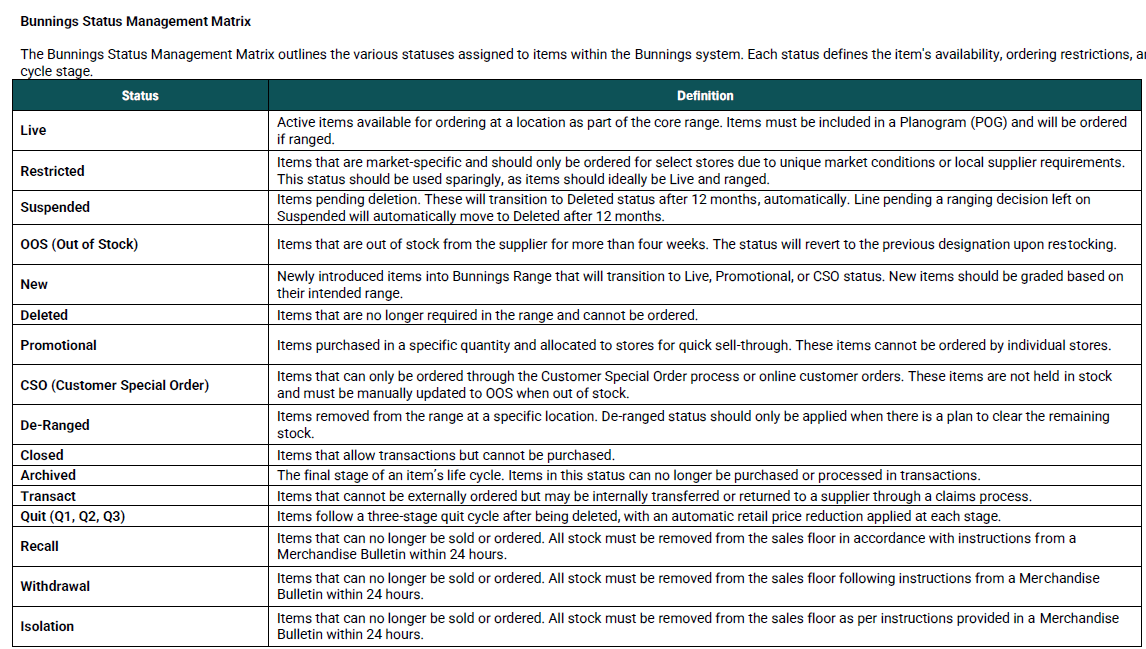

In [ ]:
len(df) #13_741_451

In [ ]:
df_filtered = df[~df['CURRENT_ITEM_STATUS_CODE'].isin([
'Deleted',
'Quit (S1)',
'Quit (S2)',
'Quit (S3)',
'Promotional',
'De-Ranged',
'Suspended',
'Withdrawal', 
'Closed',
'Promotion', 
'Archived'

])]

In [ ]:
len(df_filtered) #12_952_722

In [ ]:
# df_filtered[(df_filtered['ACTIVE_WEEKS'] != 52) & (df_filtered['FORECASTED_SALES_QUANTITY'] == 0)]['CURRENT_ITEM_STATUS_CODE'].unique()
# df_filtered[(df_filtered['ACTIVE_WEEKS'] != 52) & (df_filtered['FORECASTED_SALES_QUANTITY'] != 0)]['CURRENT_ITEM_STATUS_CODE'].unique()

df_filtered['CURRENT_ITEM_STATUS_CODE'].unique()

In [ ]:
df_filtered.isna().sum()

In [ ]:
df_filtered[df_filtered['WOS'].isna()].to_csv('wos_na.csv', index=False)

In [ ]:
df_filtered[['UNK_SALES_QTY_52W']]

In [ ]:
import plotly.graph_objects as go
from snowflakes import snowflake_connect

TOP_N = 1  # item-locations to display

ts_sql = f"""
WITH params AS (
    SELECT
        DATEADD(day, -1, CURRENT_DATE()) AS sales_end_date,
        DATEADD(week, -52, DATEADD(day, -1, CURRENT_DATE())) AS sales_start_date
),

live_planograms AS (
    SELECT DW_PLANOGRAM_ID
    FROM BDWPRD_CDS.SPACE_PLANNING.PLANOGRAM_DIM
    WHERE PLANOGRAM_STATUS_CODE = 'LIVE'
      AND PLANOGRAM_DEPARTMENT_NAME = '300 KITCHEN AND APPLIANCES'
      AND PLANOGRAM_EFFECTIVE_TO_DATE IS NULL
),

item_locations AS (
    SELECT DISTINCT ilp.DW_ITEM_ID, ilp.DW_LOCATION_ID
    FROM BDWPRD_CDS.SPACE_PLANNING.PLANOGRAM_ITEM_LOCATION_BRIDGE ilp
    JOIN live_planograms lp ON ilp.DW_PLANOGRAM_ID = lp.DW_PLANOGRAM_ID
),

-- Pick top N item-locations by total forecasted sales over 52 weeks
top_items AS (
    SELECT il.DW_ITEM_ID, il.DW_LOCATION_ID
    FROM item_locations il
    CROSS JOIN params p
    LEFT JOIN BDWPRD_CDS.SALES.FORECASTED_SALES_ITEM_LOCATION_WEEK_FCT f
        ON  f.DW_ITEM_ID    = il.DW_ITEM_ID
        AND f.DW_LOCATION_ID = il.DW_LOCATION_ID
        AND CAST(f.PERIOD_DATE AS DATE) > p.sales_start_date
        AND CAST(f.PERIOD_DATE AS DATE) <= p.sales_end_date
    GROUP BY il.DW_ITEM_ID, il.DW_LOCATION_ID
    ORDER BY SUM(COALESCE(f.FORECAST_TOTAL_SALES_QUANTITY, 0)) DESC
    LIMIT {TOP_N}
),

-- Weekly actual sales (aggregated from daily)
weekly_actual AS (
    SELECT
        DATE_TRUNC('week', CAST(s.PERIOD_DATE AS DATE)) AS week_start,
        s.DW_ITEM_ID,
        s.DW_LOCATION_ID,
        SUM(COALESCE(s.SALES_QUANTITY, 0)) AS actual_qty
    FROM BDWPRD_CDS.SALES.SALES_ITEM_LOCATION_DAY_FCT s
    JOIN top_items ti
        ON  s.DW_ITEM_ID    = ti.DW_ITEM_ID
        AND s.DW_LOCATION_ID = ti.DW_LOCATION_ID
    CROSS JOIN params p
    WHERE CAST(s.PERIOD_DATE AS DATE) > p.sales_start_date
      AND CAST(s.PERIOD_DATE AS DATE) <= p.sales_end_date
    GROUP BY 1, 2, 3
),

-- Latest forecast record per item-location per week
forecast_latest AS (
    SELECT
        CAST(f.PERIOD_DATE AS DATE) AS week_start,
        f.DW_ITEM_ID,
        f.DW_LOCATION_ID,
        FIRST_VALUE(COALESCE(f.FORECAST_TOTAL_SALES_QUANTITY, 0))
            OVER (
                PARTITION BY f.DW_ITEM_ID, f.DW_LOCATION_ID, CAST(f.PERIOD_DATE AS DATE)
                ORDER BY f.FORECAST_DATE DESC
            ) AS forecast_qty
    FROM BDWPRD_CDS.SALES.FORECASTED_SALES_ITEM_LOCATION_WEEK_FCT f
    JOIN top_items ti
        ON  f.DW_ITEM_ID    = ti.DW_ITEM_ID
        AND f.DW_LOCATION_ID = ti.DW_LOCATION_ID
    CROSS JOIN params p
    WHERE CAST(f.PERIOD_DATE AS DATE) > p.sales_start_date
      AND CAST(f.PERIOD_DATE AS DATE) <= p.sales_end_date
),

forecast_deduped AS (
    SELECT DISTINCT week_start, DW_ITEM_ID, DW_LOCATION_ID, forecast_qty
    FROM forecast_latest
),

combined AS (
    SELECT
        COALESCE(wa.week_start,   fd.week_start)   AS week_start,
        COALESCE(wa.DW_ITEM_ID,   fd.DW_ITEM_ID)   AS DW_ITEM_ID,
        COALESCE(wa.DW_LOCATION_ID, fd.DW_LOCATION_ID) AS DW_LOCATION_ID,
        COALESCE(wa.actual_qty,   0)                AS actual_qty,
        COALESCE(fd.forecast_qty, 0)                AS forecast_qty
    FROM weekly_actual wa
    FULL OUTER JOIN forecast_deduped fd
        ON  wa.week_start    = fd.week_start
        AND wa.DW_ITEM_ID    = fd.DW_ITEM_ID
        AND wa.DW_LOCATION_ID = fd.DW_LOCATION_ID
)

SELECT
    c.week_start,
    ii.ITEM_NUMBER,
    ii.ITEM_DESCRIPTION,
    l.LOCATION_NAME,
    c.actual_qty,
    c.forecast_qty
FROM combined c
JOIN BDWPRD_CDS.ITEM.ITEM_DIM ii
    ON c.DW_ITEM_ID = ii.DW_ITEM_ID
JOIN BDWPRD_CDS.LOCATION.LOCATION_DIM l
    ON c.DW_LOCATION_ID = l.DW_LOCATION_ID
ORDER BY c.DW_ITEM_ID, c.DW_LOCATION_ID, c.week_start
"""

_conn = snowflake_connect()
with _conn.cursor() as cur:
    cur.execute(ts_sql)
    ts_df = cur.fetch_pandas_all()
_conn.close()

ts_df['ITEM_LOCATION'] = ts_df['ITEM_NUMBER'].astype(str) + ' | ' + ts_df['LOCATION_NAME']

fig = go.Figure()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', "#9454d0"]

for i, (item_loc, grp) in enumerate(ts_df.groupby('ITEM_LOCATION')):
    color = colors[i % len(colors)]
    grp = grp.sort_values('WEEK_START')
    label = f"{item_loc}"

    fig.add_trace(go.Scatter(
        x=grp['WEEK_START'], y=grp['ACTUAL_QTY'],
        name=f'{label} — Actual',
        mode='lines+markers',
        line=dict(color=color, width=2),
        marker=dict(size=4),
        hovertemplate='%{x|%Y-%m-%d}<br>Actual: %{y:,.0f}<extra>' + label + '</extra>',
    ))
    fig.add_trace(go.Scatter(
        x=grp['WEEK_START'], y=grp['FORECAST_QTY'],
        name=f'{label} — Forecast',
        mode='lines',
        line=dict(color=color, width=2, dash='dash'),
        hovertemplate='%{x|%Y-%m-%d}<br>Forecast: %{y:,.0f}<extra>' + label + '</extra>',
    ))

fig.update_layout(
    title=f'Top {TOP_N} Item-Locations: Weekly Actual vs Predicted Sales (52-Week Period)',
    xaxis_title='Week',
    yaxis_title='Sales Quantity',
    height=550,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='top', y=-0.2, xanchor='left', x=0),
)

fig.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from snowflakes import snowflake_connect

# _TOP_N = TOP_N if 'TOP_N' in dir() else 5
_TOP_N = 10000000000000


_ts_sql = f"""
WITH params AS (
    SELECT
        DATEADD(day, -1, CURRENT_DATE()) AS sales_end_date,
        DATEADD(week, -52, DATEADD(day, -1, CURRENT_DATE())) AS sales_start_date
),
live_planograms AS (
    SELECT DW_PLANOGRAM_ID
    FROM BDWPRD_CDS.SPACE_PLANNING.PLANOGRAM_DIM
    WHERE PLANOGRAM_STATUS_CODE = 'LIVE'
      AND PLANOGRAM_DEPARTMENT_NAME = '300 KITCHEN AND APPLIANCES'
      AND PLANOGRAM_EFFECTIVE_TO_DATE IS NULL
),
item_locations AS (
    SELECT DISTINCT ilp.DW_ITEM_ID, ilp.DW_LOCATION_ID
    FROM BDWPRD_CDS.SPACE_PLANNING.PLANOGRAM_ITEM_LOCATION_BRIDGE ilp
    JOIN live_planograms lp ON ilp.DW_PLANOGRAM_ID = lp.DW_PLANOGRAM_ID
),
top_items AS (
    SELECT il.DW_ITEM_ID, il.DW_LOCATION_ID
    FROM item_locations il
    CROSS JOIN params p
    LEFT JOIN BDWPRD_CDS.SALES.FORECASTED_SALES_ITEM_LOCATION_WEEK_FCT f
        ON f.DW_ITEM_ID = il.DW_ITEM_ID AND f.DW_LOCATION_ID = il.DW_LOCATION_ID
        AND CAST(f.PERIOD_DATE AS DATE) > p.sales_start_date
        AND CAST(f.PERIOD_DATE AS DATE) <= p.sales_end_date
    GROUP BY il.DW_ITEM_ID, il.DW_LOCATION_ID
    ORDER BY SUM(COALESCE(f.FORECAST_TOTAL_SALES_QUANTITY, 0)) DESC
    LIMIT {_TOP_N}
),
weekly_actual AS (
    SELECT DATE_TRUNC('week', CAST(s.PERIOD_DATE AS DATE)) AS week_start,
        s.DW_ITEM_ID, s.DW_LOCATION_ID,
        SUM(COALESCE(s.SALES_QUANTITY, 0)) AS actual_qty
    FROM BDWPRD_CDS.SALES.SALES_ITEM_LOCATION_DAY_FCT s
    JOIN top_items ti ON s.DW_ITEM_ID = ti.DW_ITEM_ID AND s.DW_LOCATION_ID = ti.DW_LOCATION_ID
    CROSS JOIN params p
    WHERE CAST(s.PERIOD_DATE AS DATE) > p.sales_start_date
      AND CAST(s.PERIOD_DATE AS DATE) <= p.sales_end_date
    GROUP BY 1, 2, 3
),
forecast_latest AS (
    SELECT CAST(f.PERIOD_DATE AS DATE) AS week_start, f.DW_ITEM_ID, f.DW_LOCATION_ID,
        FIRST_VALUE(COALESCE(f.FORECAST_TOTAL_SALES_QUANTITY, 0))
            OVER (PARTITION BY f.DW_ITEM_ID, f.DW_LOCATION_ID, CAST(f.PERIOD_DATE AS DATE)
                  ORDER BY f.FORECAST_DATE DESC) AS forecast_qty
    FROM BDWPRD_CDS.SALES.FORECASTED_SALES_ITEM_LOCATION_WEEK_FCT f
    JOIN top_items ti ON f.DW_ITEM_ID = ti.DW_ITEM_ID AND f.DW_LOCATION_ID = ti.DW_LOCATION_ID
    CROSS JOIN params p
    WHERE CAST(f.PERIOD_DATE AS DATE) > p.sales_start_date
      AND CAST(f.PERIOD_DATE AS DATE) <= p.sales_end_date
),
forecast_deduped AS (
    SELECT DISTINCT week_start, DW_ITEM_ID, DW_LOCATION_ID, forecast_qty FROM forecast_latest
),
combined AS (
    SELECT COALESCE(wa.week_start, fd.week_start) AS week_start,
        COALESCE(wa.DW_ITEM_ID, fd.DW_ITEM_ID) AS DW_ITEM_ID,
        COALESCE(wa.DW_LOCATION_ID, fd.DW_LOCATION_ID) AS DW_LOCATION_ID,
        COALESCE(wa.actual_qty, 0) AS actual_qty,
        COALESCE(fd.forecast_qty, 0) AS forecast_qty
    FROM weekly_actual wa
    FULL OUTER JOIN forecast_deduped fd
        ON wa.week_start = fd.week_start AND wa.DW_ITEM_ID = fd.DW_ITEM_ID
       AND wa.DW_LOCATION_ID = fd.DW_LOCATION_ID
)
SELECT
    c.week_start,
    ii.ITEM_NUMBER,
    ii.ITEM_DESCRIPTION,
    l.LOCATION_NAME,
    ist.CURRENT_ITEM_STATUS_CODE,
    c.actual_qty,
    c.forecast_qty
FROM combined c
JOIN BDWPRD_CDS.ITEM.ITEM_DIM ii ON c.DW_ITEM_ID = ii.DW_ITEM_ID
JOIN BDWPRD_CDS.LOCATION.LOCATION_DIM l ON c.DW_LOCATION_ID = l.DW_LOCATION_ID
LEFT JOIN (
    SELECT rs.DW_ITEM_ID, rs.DW_LOCATION_ID,
           MAX(isdim.ITEM_STATUS_CODE) AS CURRENT_ITEM_STATUS_CODE
    FROM BDWPRD_CDS.MERCHANDISING.ITEM_LOCATION_RANGING_STATS_FCT rs
    LEFT JOIN BDWPRD_CDS.COMMON.ITEM_STATUS_DIM isdim
        ON isdim.DW_ITEM_STATUS_ID = rs.DW_ITEM_STATUS_ID
    GROUP BY rs.DW_ITEM_ID, rs.DW_LOCATION_ID
) ist ON c.DW_ITEM_ID = ist.DW_ITEM_ID AND c.DW_LOCATION_ID = ist.DW_LOCATION_ID
ORDER BY c.DW_ITEM_ID, c.DW_LOCATION_ID, c.week_start
"""

_conn = snowflake_connect()
with _conn.cursor() as cur:
    cur.execute(_ts_sql)
    acc_df = cur.fetch_pandas_all()
_conn.close()

acc_df['ITEM_LOCATION'] = acc_df['ITEM_NUMBER'].astype(str) + ' | ' + acc_df['LOCATION_NAME']

overlap = acc_df[(acc_df['ACTUAL_QTY'] > 0) & (acc_df['FORECAST_QTY'] > 0)].copy()

print(f"rows fetched: {len(acc_df)}, overlap rows: {len(overlap)}")
print(acc_df[['ITEM_LOCATION', 'WEEK_START', 'ACTUAL_QTY', 'FORECAST_QTY', 'CURRENT_ITEM_STATUS_CODE']].head(1000).to_string())

if overlap.empty:
    print("\nNo weeks have both actual > 0 and forecast > 0. Cannot compute accuracy metrics.")
    print("Tip: increase TOP_N in the time series cell or check the date window.")
else:
    records = []
    for item_loc, grp in overlap.groupby('ITEM_LOCATION'):
        actual   = grp['ACTUAL_QTY'].values
        forecast = grp['FORECAST_QTY'].values
        records.append({
            'ITEM_LOCATION': item_loc,
            'MAE':           np.mean(np.abs(actual - forecast)),
            'MAPE_%':        np.mean(np.abs((actual - forecast) / actual)) * 100,
            'RMSE':          np.sqrt(np.mean((actual - forecast) ** 2)),
            'BIAS':          np.mean(forecast - actual),  # positive = over-forecast
            'OVERLAP_WEEKS': len(grp),
        })
    metrics = pd.DataFrame(records).sort_values('MAPE_%')
    print(metrics.to_string(index=False))

    fig_acc = make_subplots(
        rows=1, cols=2,
        subplot_titles=('MAPE % (lower = better)', 'Bias (+ = over-forecast, - = under-forecast)')
    )
    fig_acc.add_trace(go.Bar(
        x=metrics['MAPE_%'], y=metrics['ITEM_LOCATION'],
        orientation='h', marker_color='steelblue',
        text=metrics['MAPE_%'].round(1).astype(str) + '%',
        textposition='outside',
        hovertemplate='%{y}<br>MAPE: %{x:.1f}%<extra></extra>',
    ), row=1, col=1)
    fig_acc.add_trace(go.Bar(
        x=metrics['BIAS'], y=metrics['ITEM_LOCATION'],
        orientation='h',
        marker_color=['darkorange' if v > 0 else 'steelblue' for v in metrics['BIAS']],
        hovertemplate='%{y}<br>Bias: %{x:.1f}<extra></extra>',
    ), row=1, col=2)
    fig_acc.update_layout(
        title='Forecast Accuracy - Weeks with Both Actual & Predicted Sales',
        height=max(300, 60 * len(metrics) + 120),
        showlegend=False,
        margin=dict(l=300),
    )
    fig_acc.show()
